>**⚠️ Kernel:** Click **Select Kernel** (top right) → **Python Environments...** → **genomad (Python 3.10.20)** <br />

A few additional steps are needed in the terminal before being able to continue:

```bash
eval "$(micromamba shell hook --shell bash)"
micromamba activate genomad
micromamba install -n genomad ipykernel matplotlib pandas --force-reinstall
```

# Beyond contigs

The contigs assembled from metagenomic reads are not exclusively bacterial. Because bulk-metagenomes include everything that was in the sample, we can also have viral, plasmid, and  eukaryotic contigs.

## geNomad can distinguish viral and plasmid contigs very efficiently
https://github.com/apcamargo/genomad 

Check that geNomad is installed, and its usage:

In [ ]:
%%bash

which genomad

genomad --help
#genomad download-database --help
#genomad end-to-end --help

Download the geNomad database (needs 1.5TB free disk space)

In [25]:
%%bash

mkdir -p /biodata/resources/MGX_assembly/genomad_db
genomad download-database --quiet /biodata/resources/MGX_assembly/genomad_db

# Check the database files
ls /biodata/resources/MGX_assembly/genomad_db/genomad_db

Run geNomad's `end-to-end` workflow

In [23]:
%%bash

# Delete the previous run of genomad and re-create the output directory
rm -rf /biodata/resources/MGX_assembly/assembly/genomad
mkdir -p /biodata/resources/MGX_assembly/assembly/genomad

# Run genomad end-to-end with the specified parameters
genomad end-to-end \
    --cleanup --disable-nn-classification --sensitivity 2.0 --quiet \
    /biodata/resources/MGX_assembly/assembly/contig_demo/25748.contigs.fa \
    /biodata/resources/MGX_assembly/assembly/genomad \
    /biodata/resources/MGX_assembly/genomad_db/genomad_db/

# Check the contents of the output directory
ls /biodata/resources/MGX_assembly/assembly/genomad

25748.contigs_annotate
25748.contigs_annotate.log
25748.contigs_find_proviruses
25748.contigs_find_proviruses.log
25748.contigs_marker_classification
25748.contigs_marker_classification.log
25748.contigs_summary
25748.contigs_summary.log


<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>💡 Hint:</strong> Configuration

For this run we used `--disable-nn-classification` and `--sensitivity 2.0` for a faster run. In a real time scenario, those parameters should be reviewed or removed. 

</div>


In [36]:
%%bash

# Check the contents of the summary files generated by genomad
echo "-> Virus summary:"
echo "-------"
head -5 /biodata/resources/MGX_assembly/assembly/genomad/25748.contigs_summary/25748.contigs_virus_summary.tsv

echo "-> Plasmid summary:"
echo "-------"
head -5 /biodata/resources/MGX_assembly/assembly/genomad/25748.contigs_summary/25748.contigs_plasmid_summary.tsv

-> Virus summary:
-------
seq_name	length	topology	coordinates	n_genes	genetic_code	virus_score	fdr	n_hallmarks	marker_enrichment	taxonomy
k141_114|provirus_20057_78162	58106	Provirus	20057-78162	42	11	0.9968	NA	3	49.0208	Viruses;Duplodnaviria;Heunggongvirae;Uroviricota;Caudoviricetes;;
k141_100|provirus_9209_40928	31720	Provirus	9209-40928	35	11	0.9965	NA	9	39.3748	Viruses;Duplodnaviria;Heunggongvirae;Uroviricota;Caudoviricetes;;
k141_50|provirus_114948_143994	29047	Provirus	114948-143994	35	11	0.9963	NA	11	53.0167	Viruses;Duplodnaviria;Heunggongvirae;Uroviricota;Caudoviricetes;;
k141_74|provirus_4768_33669	28902	Provirus	4768-33669	52	11	0.9955	NA	1	31.2270	Viruses;Duplodnaviria;Heunggongvirae;Uroviricota;Caudoviricetes;;
-> Plasmid summary:
-------
seq_name	length	topology	n_genes	genetic_code	plasmid_score	fdr	n_hallmarks	marker_enrichment	conjugation_genes	amr_genes
k141_32	13857	No terminal repeats	20	11	0.9941	NA	2	9.6559	NA	NA
k141_12	15041	No terminal repeats	21	11	0.9724	NA	0

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question:</strong> From our assembled contigs, how many are identified as Virus or Plasmids?
</div> <br />

<details>
<summary><strong>🔎 Solution :</strong></summary>

```python
import pandas as pd
import matplotlib.pyplot as plt

contigs_file = "/biodata/resources/MGX_assembly/assembly/contig_demo/25748.contigs.fa"
virus_file = "/biodata/resources/MGX_assembly/assembly/genomad/25748.contigs_summary/25748.contigs_virus_summary.tsv"
plasmid_file = "/biodata/resources/MGX_assembly/assembly/genomad/25748.contigs_summary/25748.contigs_plasmid_summary.tsv"

total_contigs = sum(1 for line in open(contigs_file) if line.startswith(">"))
viral_contigs = len(pd.read_csv(virus_file, sep="\t"))
plasmid_contigs = len(pd.read_csv(plasmid_file, sep="\t"))

labels = ["Total contigs", "Viral", "Plasmids"]
counts = [total_contigs, viral_contigs, plasmid_contigs]

fig, ax = plt.subplots()
bars = ax.bar(labels, counts, color=["steelblue", "tomato", "mediumseagreen"])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of contigs")
ax.set_title("Contig classification")
plt.show()
```

</details>

In [35]:
# your answer here

## The assembled contigs are the starting point for many other different analysis

We support some of them with MetaGEAR: https://metagear-platform.schirmerlab.de

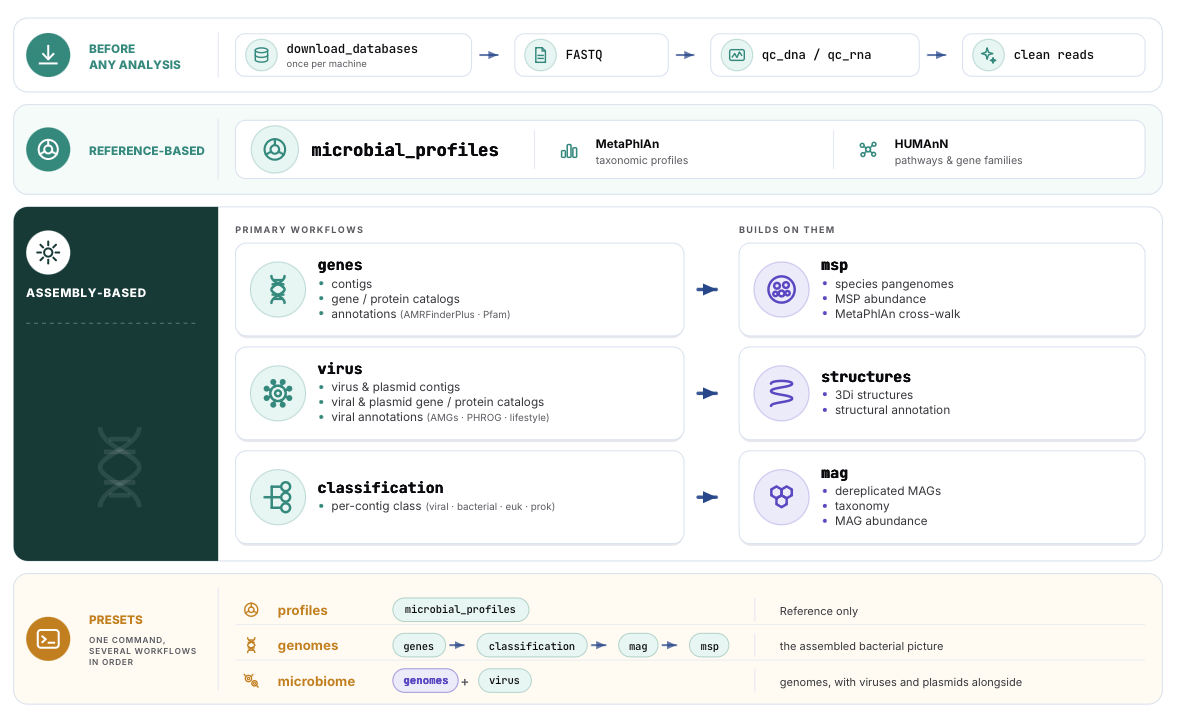